# Spotify Perú — El ADN Musical del Mercado Peruano
## Business Analytics · AD3010 · UTEC

**Consultora de datos** para una distribuidora musical latinoamericana que evalúa **entrar al mercado peruano**.

**Pregunta de negocio**
> ¿Cuáles son los atributos, géneros y artistas que definen la identidad del consumo musical en Perú, y cómo divergen estas tendencias del segmento universitario?

**Integrantes:** Yupanqui López, Milagros Valeria · Condori Pari, Isabel Violeta · Patiño Landa, Jennifer Jireh · Suarez Arce, Tana Sofía
**Docente:** Prof. Alan Morante

---

### Hoja de ruta del notebook

| # | Bloque | Técnica (rúbrica) |
|---|--------|-------------------|
| 0 | Setup e *imports* | — |
| 1 | Dataset A — carga, limpieza y EDA | EDA / calidad de datos |
| 2 | Dataset B — validación corte reciente | EDA |
| 3 | Dataset C — encuesta de enriquecimiento (en vivo) | Enriquecimiento |
| 4 | P1 · Héroes regionales (IRL) | EDA + KPI |
| 5 | P2 · Estabilidad de atributos (CV) | EDA + KPI |
| 6 | P3 · Perú vs. resto de LATAM | EDA + KPI |
| 7 | **Series de tiempo · descomposición + forecasting** | **5.5 Series de tiempo** |
| 8 | P4 · Universitarios vs. ranking nacional (IAM) | Enriquecimiento + KPI |
| 9 | P5 · Canal de descubrimiento → gasto (IVC) | Enriquecimiento + KPI |
| 10 | **Segmentación · clustering de perfiles sonoros** | **5.7 No supervisado** |
| 11 | **Modelo A · perfilador sonoro (clasificación)** | **5.3 Supervisado** |
| 12 | **Modelo B · ¿el sonido predice el éxito? (logística)** | **5.3 Supervisado** |
| 13 | Match encuesta ↔ perfiles · la brecha oferta/demanda | Enriquecimiento |
| 14 | Síntesis ejecutiva y recomendaciones | Storytelling |
| 15 | Exports para Power BI | 5.6 Visualización |

> **Nota de reproducibilidad.** El dataset base se actualiza a diario en Kaggle y la encuesta se lee en vivo desde Google Sheets, por lo que los valores absolutos pueden variar levemente entre corridas. La estructura de los hallazgos (perfil dominante, fragmentación universitaria, baja capacidad predictiva del audio) se mantiene estable.

## 0. Setup e *imports*

Cargamos librerías de manipulación de datos, visualización, *machine learning* (scikit-learn) y series de tiempo (statsmodels). Fijamos una semilla global para reproducibilidad.

In [ ]:
# 📦 Imports
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, classification_report,
                             confusion_matrix, roc_auc_score, accuracy_score)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Series de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Descarga del dataset base
import kagglehub

# Reproducibilidad y estilo
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Dataset A — Top Spotify Songs in 73 Countries (histórico, actualización diaria)

**Fuente:** Kaggle · `asaniczka/top-spotify-songs-in-73-countries-daily-updated`
**Rol:** representa la dinámica histórica del mercado. Cada fila es la posición diaria de una canción en el Top 50 de un país, con sus *audio features*. Es nuestra materia prima para perfiles sonoros, evolución temporal y comparación regional.

**Llave de unión con el Dataset B:** `spotify_id`.

In [ ]:
# Descarga del dataset base desde Kaggle
path = kagglehub.dataset_download("asaniczka/top-spotify-songs-in-73-countries-daily-updated")
archivo = [x for x in os.listdir(path) if x.endswith(".csv")][0]
df_topglobal = pd.read_csv(os.path.join(path, archivo))
print(f"Dataset A cargado: {df_topglobal.shape[0]:,} filas × {df_topglobal.shape[1]} columnas")
df_topglobal.head(3)

Using Colab cache for faster access to the 'top-spotify-songs-in-73-countries-daily-updated' dataset.
Dataset A cargado: 2,110,316 filas × 25 columnas


,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,Alex Warren,1,1,0,NaN,2025-06-11,95,False,...,2,-6.141,1,0.0600,0.704000,0.000007,0.0550,0.391,168.115,3
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,Sabrina Carpenter,2,-1,48,NaN,2025-06-11,89,True,...,7,-5.087,1,0.0572,0.122000,0.000000,0.3170,0.811,123.010,4
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,sombr,3,0,1,NaN,2025-06-11,98,False,...,1,-2.291,1,0.0301,0.000094,0.000088,0.0929,0.235,92.855,4


**Diccionario de variables clave**

| Variable | Tipo | Relevancia de negocio |
|---|---|---|
| `spotify_id` | alfanumérico | Llave primaria; une A con B sin duplicidad |
| `country` | categórico | Filtro de mercado (PE = Perú) |
| `snapshot_date` | fecha | Permite medir persistencia y construir la serie de tiempo |
| `daily_rank` | numérico | Posición diaria en el Top 50 |
| `popularity` | entero (0–100) | Éxito masivo global; clave para detectar "héroes regionales" |
| `danceability` | decimal (0–1) | Qué tan bailable; factor central de la cultura musical peruana |
| `energy` | decimal (0–1) | Intensidad/actividad de la pista |
| `valence` | decimal (0–1) | Positividad emocional de la canción |

### 1.1 Limpieza del Dataset A

Aplicamos cuatro pasos de saneamiento: (1) eliminar registros sin identificadores esenciales, (2) quitar duplicados exactos, (3) tipar `snapshot_date` como fecha, y (4) revisar el resumen estadístico para detectar rangos anómalos.

In [ ]:
# (1) Valores nulos en campos esenciales
nulos_antes = df_topglobal.isnull().sum().sum()
df_topglobal = df_topglobal.dropna(subset=["spotify_id", "name", "artists"])
print(f"Nulos totales antes: {nulos_antes:,} | filas tras eliminar nulos esenciales: {df_topglobal.shape[0]:,}")

# (2) Duplicados exactos
dups = df_topglobal.duplicated().sum()
if dups > 0:
    df_topglobal = df_topglobal.drop_duplicates()
print(f"Duplicados eliminados: {dups:,}")

# (3) Tipado de fecha
df_topglobal["snapshot_date"] = pd.to_datetime(df_topglobal["snapshot_date"])
print(f"Rango temporal: {df_topglobal['snapshot_date'].min().date()} → {df_topglobal['snapshot_date'].max().date()}")

Nulos totales antes: 30,448 | filas tras eliminar nulos esenciales: 2,110,286
Duplicados eliminados: 0
Rango temporal: 2023-10-18 → 2025-06-11


In [ ]:
# (4) Resumen estadístico de las features de audio (rango esperado 0-1, salvo loudness/tempo)
cols_audio = ["danceability", "energy", "valence", "acousticness",
              "speechiness", "instrumentalness", "liveness", "loudness", "tempo", "popularity"]
df_topglobal[cols_audio].describe().round(3)

,danceability,energy,valence,acousticness,speechiness,instrumentalness,liveness,loudness,tempo,popularity
count,2110286.000,2110286.000,2110286.000,2110286.000,2110286.000,2110286.000,2110286.000,2110286.000,2110286.000,2110286.000
mean,0.676,0.649,0.546,0.275,0.096,0.023,0.171,-6.772,122.101,75.908
std,0.144,0.169,0.231,0.251,0.091,0.114,0.125,3.875,27.819,15.761
min,0.000,0.000,0.000,0.000,0.000,0.000,0.014,-54.341,0.000,0.000
25%,0.580,0.552,0.370,0.067,0.038,0.000,0.096,-7.830,100.019,65.000
50%,0.700,0.668,0.548,0.191,0.058,0.000,0.122,-6.064,119.965,79.000
75%,0.780,0.767,0.733,0.437,0.112,0.000,0.204,-4.723,140.021,88.000
max,0.988,0.998,0.992,0.996,0.957,0.995,0.983,3.233,236.089,100.000


### 1.2 Filtrado del mercado peruano (`df_topperu`)

Filtramos `country == 'PE'` para aislar el Top 50 histórico de Perú, que es el foco del análisis nacional.

In [ ]:
df_topperu = df_topglobal[df_topglobal["country"] == "PE"].copy()
print(f"Registros del Top 50 Perú (histórico): {df_topperu.shape[0]:,}")
print(f"Canciones únicas: {df_topperu['spotify_id'].nunique():,} | Artistas únicos: {df_topperu['artists'].nunique():,}")
df_topperu[["danceability", "energy", "valence", "popularity"]].describe().round(3)

Registros del Top 50 Perú (histórico): 29,054
Canciones únicas: 439 | Artistas únicos: 270


,danceability,energy,valence,popularity
count,29054.000,29054.000,29054.000,29054.000
mean,0.736,0.681,0.601,83.834
std,0.139,0.150,0.220,9.134
min,0.094,0.000,0.000,0.000
25%,0.685,0.626,0.446,81.000
50%,0.763,0.705,0.602,85.000
75%,0.831,0.774,0.788,89.000
max,0.932,0.981,0.980,100.000


## 2. Dataset B — Top 50 Perú (corte reciente, 25/04/2026)

**Fuente:** GitHub (CSV público) · **Rol:** foto puntual del consumo actual peruano. Sirve como *dataset de validación*: confirma que los patrones del histórico (alta bailabilidad/energía) siguen vigentes en el corte más reciente.

Las columnas `Dance/Energy/Valence` vienen en escala 0–100, así que las normalizamos a 0–1 para que sean comparables con el Dataset A.

In [ ]:
url_b = "https://raw.githubusercontent.com/miyulo139/spotifycsv/refs/heads/main/Top%2050%20-%20Peru.csv"
df_topperuhoy = pd.read_csv(url_b)
print(f"Dataset B cargado: {df_topperuhoy.shape[0]} filas × {df_topperuhoy.shape[1]} columnas")

# Normalización 0-100 -> 0-1 y armonización de nombres con el Dataset A
df_b = df_topperuhoy.copy()
df_b = df_b.rename(columns={"Dance": "danceability", "Energy": "energy", "Valence": "valence"})
for col in ["danceability", "energy", "valence"]:
    if df_b[col].max() > 1.5:        # está en escala 0-100
        df_b[col] = df_b[col] / 100
df_b[["danceability", "energy", "valence"]].describe().round(3)

Dataset B cargado: 49 filas × 25 columnas


,danceability,energy,valence
count,49.00,49.000,49.000
mean,0.69,0.649,0.537
std,0.16,0.205,0.226
min,0.17,0.000,0.030
25%,0.64,0.540,0.430
50%,0.72,0.700,0.500
75%,0.77,0.800,0.700
max,0.93,0.980,0.960


### 2.1 Validación: el corte reciente confirma el histórico

Comparamos los promedios del histórico (`df_topperu`) con el corte actual (`df_b`). La cercanía entre ambos confirma que la preferencia por música bailable y enérgica **no es una moda pasajera**, sino un patrón estructural sostenido.

,Histórico (Dataset A),Corte actual (Dataset B)
danceability,0.736,0.690
energy,0.681,0.649
valence,0.601,0.537


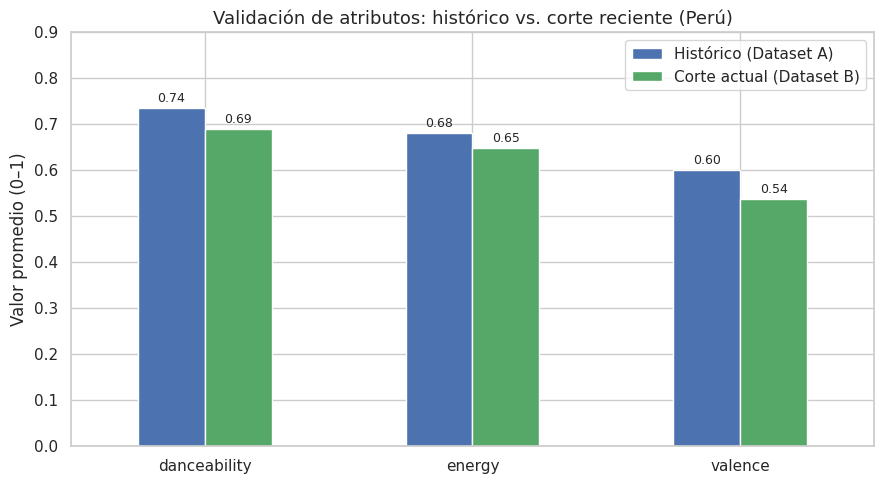

In [ ]:
comp_val = pd.DataFrame({
    "Histórico (Dataset A)": df_topperu[["danceability", "energy", "valence"]].mean(),
    "Corte actual (Dataset B)": df_b[["danceability", "energy", "valence"]].mean(),
}).round(3)
display(comp_val)

ax = comp_val.plot.bar(rot=0, figsize=(9, 5), color=["#4C72B0", "#55A868"])
ax.set_title("Validación de atributos: histórico vs. corte reciente (Perú)")
ax.set_ylabel("Valor promedio (0–1)"); ax.set_ylim(0, 0.9)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=9)
plt.tight_layout(); plt.show()

## 3. Dataset C — Encuesta de enriquecimiento (segmento universitario UTEC)

**Fuente:** Google Forms aplicado en campus, leído **en vivo** desde Google Sheets (34 respuestas).
**Rol:** captura variables de comportamiento que los metadatos de Spotify **no registran**: hábitos de descubrimiento, lealtad al artista, contexto de escucha y disposición de gasto.

**Por qué es indispensable.** Spotify dice *qué* se escucha, pero no *por qué* ni *quién paga*. Sin la encuesta no podríamos responder las preguntas P4 y P5, ni medir la brecha entre la oferta del mercado y la demanda del segmento joven.

In [ ]:
# Encuesta en vivo (CSV publicado desde Google Sheets)
ENCUESTA_URL = ("https://docs.google.com/spreadsheets/d/e/"
    "2PACX-1vSBGsDZQVnuMAzP3HffDALUEc_jIgLt3wRpCKa-ww9_VNDWZzXcPAJgGWYw2EnONIT5PX-kkiBjzgER"
    "/pub?gid=0&single=true&output=csv")
df = pd.read_csv(ENCUESTA_URL)
df_original = df.copy()       # backup de validación
print(f"Encuesta cargada: {df.shape[0]} respuestas × {df.shape[1]} preguntas")
df.head(3)

Encuesta cargada: 77 respuestas × 16 preguntas


,descubrimiento_ultima_cancion,descubrimiento_penultima_cancion,plataforma_frecuente,influencia_tendencias,fidelidad_artista_lanzamiento,valoracion_letras,valoracion_produccion,valoracion_en_vivo,valoracion_personalidad_redes,apertura_generos_nuevos,ritmo_predominante,artista_top1,artista_top2,momento_maxima_atencion,tipo_suscripcion,gasto_mayor_apoyo_artista
0,Descubrimiento propio (Búsqueda intencional),Descubrimiento propio (Búsqueda intencional),YouTube / YouTube Music,"Poco, solo lo escucho si el género es de mi ag...","Le doy un par de oportunidades, pero si no me ...",Poco importante,Muy importante,Nada importante,Poco importante,5,Híbrido: Cambio según lo que el algoritmo me s...,Ninguno,Ninguno,Transporte público (Trayectos),No aplica (Escucho en YouTube o radio).,"Ninguna, solo consumo música en plataformas di..."
1,TikTok,TikTok,Spotify,"Poco, solo lo escucho si el género es de mi ag...",Paso al siguiente artista; no pierdo tiempo si...,Importante,Importante,Poco importante,Importante,5,Híbrido: Cambio según lo que el algoritmo me s...,Jimin,Bad Bunny,Transporte público (Trayectos),Plan familiar / Estudiantil.,"Ninguna, solo consumo música en plataformas di..."
2,Recomendación de amigos/familiares,TikTok,Spotify,"Poco, solo lo escucho si el género es de mi ag...","Le doy un par de oportunidades, pero si no me ...",Importante,Importante,Importante,Poco importante,5,Melancólico o sentimental: Conexión emocional ...,Ninguno,Ninguno,Transporte público (Trayectos),Gratuita (Con anuncios).,Entradas a conciertos / Festivales


### 3.1 Normalización de respuestas

Las respuestas vienen como texto largo de Google Forms. Las recodificamos a etiquetas cortas y consistentes para facilitar el análisis y los gráficos. Conservamos el texto original en `df_original`.

In [ ]:
replacement_maps = {
    "descubrimiento_ultima_cancion": {
        "Descubrimiento propio (Búsqueda intencional)": "busqueda_intencional",
        "TikTok": "tiktok", "Recomendación de amigos/familiares": "recomendacion_personal",
        "Spotify (Descubrimiento/Playlist)": "algoritmo_streaming",
        "Reels (Instagram/Facebook)": "reels", "Radio (Convencional)": "radio_tradicional"},
    "descubrimiento_penultima_cancion": {
        "Descubrimiento propio (Búsqueda intencional)": "busqueda_intencional",
        "TikTok": "tiktok", "Recomendación de amigos/familiares": "recomendacion_personal",
        "Spotify (Descubrimiento/Playlist)": "algoritmo_streaming",
        "Radio (Convencional)": "radio_tradicional", "Reels (Instagram/Facebook)": "reels"},
    "plataforma_frecuente": {
        "YouTube / YouTube Music": "youtube", "Spotify": "spotify",
        "Otras plataformas de streaming (Apple Music, Deezer, Tidal)": "otros_streaming",
        "Archivos locales o descargados (MP3 / Apps de descarga)": "offline_local"},
    "influencia_tendencias": {
        "Mucho, me gusta estar al día con lo que todos escuchan para poder participar en la conversación.": "alta",
        "Poco, solo lo escucho si el género es de mi agrado personal.": "media_baja",
        "Nada, prefiero descubrir música por mi cuenta sin importar si es popular o no.": "nula"},
    "fidelidad_artista_lanzamiento": {
        "Le doy un par de oportunidades, pero si no me gusta, dejo de escucharlo.": "tolerante",
        "Paso al siguiente artista; no pierdo tiempo si no conecto a la primera.": "baja_tolerancia"},
    "ritmo_predominante": {
        "Híbrido: Cambio según lo que el algoritmo me sugiera en el momento.": "hibrido_variable",
        "Melancólico o sentimental: Conexión emocional con la letra (Baladas, Art-Pop).": "emocional_lento",
        "Intenso y con fuerza: No necesariamente bailable (Rock, Metal, Electrónica).": "intenso_fuerte",
        "Energía alta y bailable: Para activarme o salir (Reggaetón, Cumbia, Pop movido).": "energico_bailable",
        "Tranquilo y de baja intensidad: Para concentración o calma (Lo-fi, Indie, Acústicos).": "relajado_suave"},
    "momento_maxima_atencion": {
        "Transporte público (Trayectos)": "transito",
        "Momentos sociales (Previas, reuniones, fiestas)": "social",
        "Relax / Antes de dormir": "relax", "Estudio / Tareas académicas": "concentracion",
        "Gimnasio / Deporte": "deporte"},
    "tipo_suscripcion": {
        "No aplica (Escucho en YouTube o radio).": "ninguna",
        "Plan familiar / Estudiantil.": "plan_especial",
        "Gratuita (Con anuncios).": "freemium", "Premium (Pago mensual).": "premium"},
    "gasto_mayor_apoyo_artista": {
        "Ninguna, solo consumo música en plataformas digitales.": "solo_streaming",
        "Entradas a conciertos / Festivales": "eventos_vivo"},
}
for col, mapping in replacement_maps.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)
print("Respuestas normalizadas.")
df[["ritmo_predominante", "descubrimiento_ultima_cancion", "tipo_suscripcion", "gasto_mayor_apoyo_artista"]].head()

Respuestas normalizadas.


,ritmo_predominante,descubrimiento_ultima_cancion,tipo_suscripcion,gasto_mayor_apoyo_artista
0,hibrido_variable,busqueda_intencional,ninguna,solo_streaming
1,hibrido_variable,tiktok,plan_especial,solo_streaming
2,emocional_lento,recomendacion_personal,freemium,eventos_vivo
3,hibrido_variable,tiktok,ninguna,solo_streaming
4,intenso_fuerte,busqueda_intencional,ninguna,solo_streaming


### 3.2 EDA rápido de la encuesta

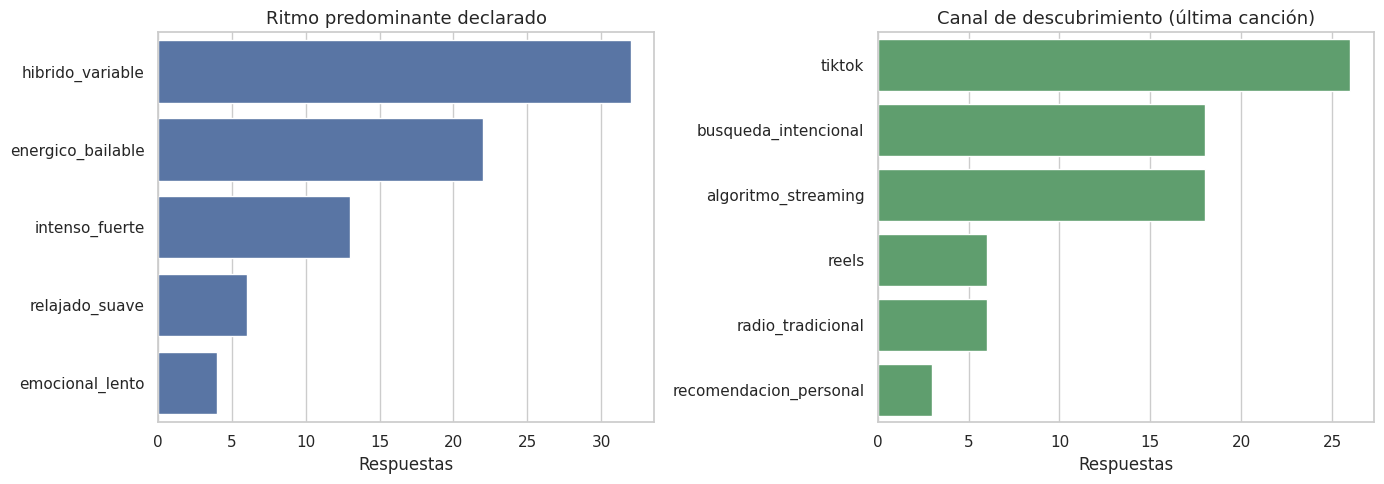

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(y="ritmo_predominante", data=df,
              order=df["ritmo_predominante"].value_counts().index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Ritmo predominante declarado"); axes[0].set_xlabel("Respuestas"); axes[0].set_ylabel("")
sns.countplot(y="descubrimiento_ultima_cancion", data=df,
              order=df["descubrimiento_ultima_cancion"].value_counts().index, ax=axes[1], color="#55A868")
axes[1].set_title("Canal de descubrimiento (última canción)"); axes[1].set_xlabel("Respuestas"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

## 4. Pregunta 1 · ¿Qué artistas triunfan en Perú pese a baja popularidad global?

**Objetivo:** detectar "héroes regionales" — fenómenos locales con alto potencial y bajo costo de contratación.
**KPI · Índice de Relevancia Local (IRL):** relación entre la frecuencia de aparición de un artista en el Top Perú y su popularidad global.
Un artista con **IRL alto y popularidad global < 65** tiene demanda local desproporcionada a su escala mundial.

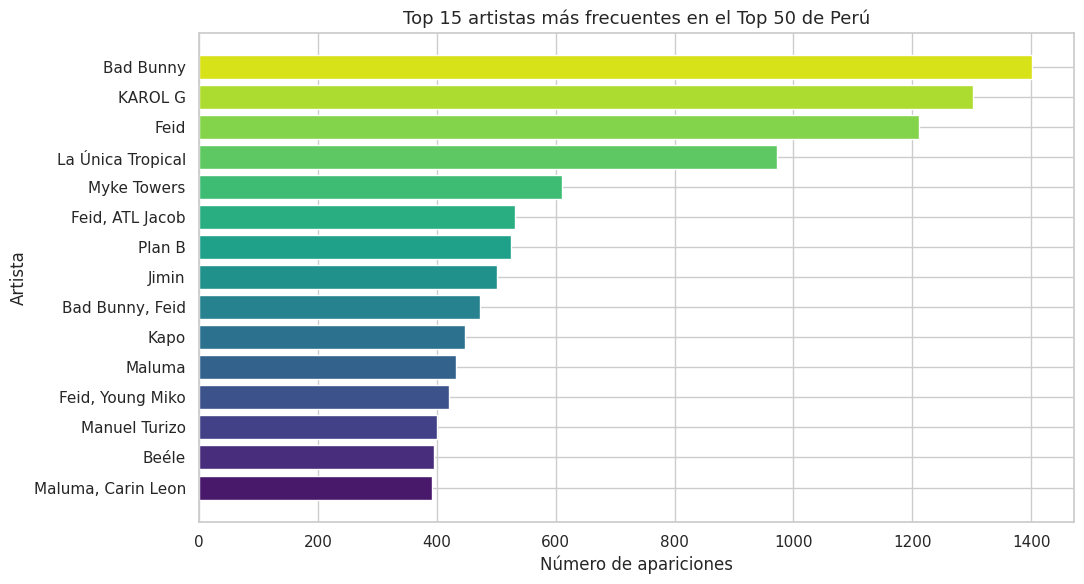

In [ ]:
# Top 15 artistas por frecuencia de aparición en el Top 50 Perú
top_artists = df_topperu["artists"].value_counts().nlargest(15)

plt.figure(figsize=(11, 6))
colors = sns.color_palette("viridis", len(top_artists))
plt.barh(top_artists.index[::-1], top_artists.values[::-1], color=colors)
plt.title("Top 15 artistas más frecuentes en el Top 50 de Perú")
plt.xlabel("Número de apariciones"); plt.ylabel("Artista")
plt.tight_layout(); plt.show()

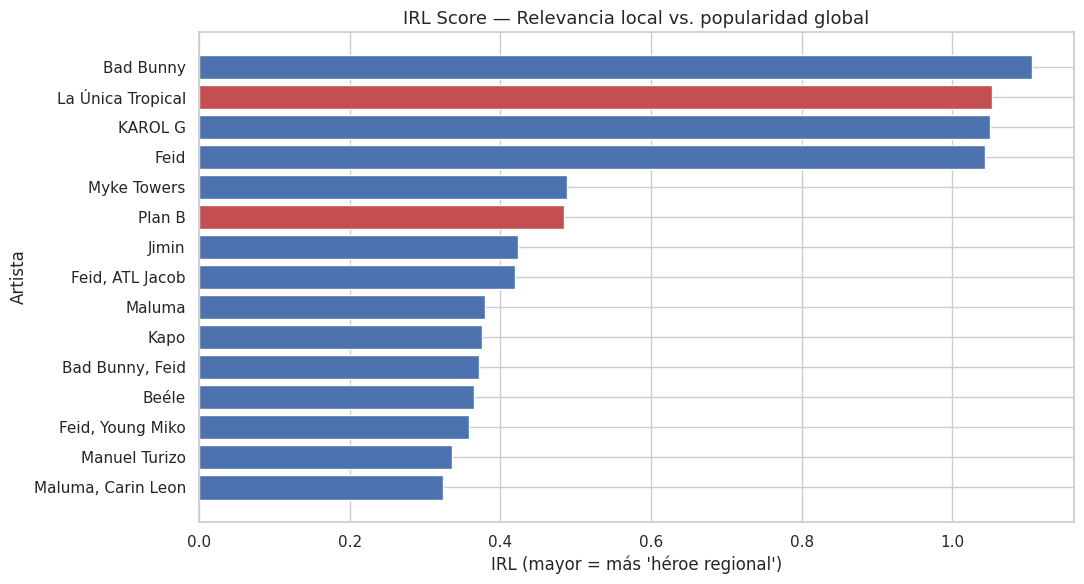

,peru_freq,pop_global,IRL
artists,,,
Bad Bunny,1402,90.39,1.11
La Única Tropical,973,65.94,1.05
KAROL G,1302,88.45,1.05
Feid,1212,82.82,1.04
Myke Towers,610,89.12,0.49
Plan B,525,77.30,0.48
Jimin,502,84.63,0.42
"Feid, ATL Jacob",532,90.42,0.42
Maluma,432,81.26,0.38


In [ ]:
# Popularidad global promedio de esos mismos artistas
pop_global = (df_topglobal[df_topglobal["artists"].isin(top_artists.index)]
              .groupby("artists")["popularity"].mean())

# Construcción del IRL = frecuencia_relativa_Peru / (popularidad_global/100)
irl = pd.DataFrame({"peru_freq": top_artists}).join(pop_global.rename("pop_global"))
irl["IRL"] = (irl["peru_freq"] / irl["peru_freq"].max()) / (irl["pop_global"] / 100)
irl = irl.sort_values("IRL", ascending=False)

plt.figure(figsize=(11, 6))
colors = ["#C44E52" if (r.IRL > irl["IRL"].median() and r.pop_global < 80) else "#4C72B0"
          for r in irl.itertuples()]
plt.barh(irl.index[::-1], irl["IRL"].values[::-1], color=colors[::-1])
plt.title("IRL Score — Relevancia local vs. popularidad global")
plt.xlabel("IRL (mayor = más 'héroe regional')"); plt.ylabel("Artista")
plt.tight_layout(); plt.show()

irl.round(2)

**Hallazgo.** Artistas como **La Única Tropical, Myke Towers y Plan B** muestran IRL elevado con popularidad global comparativamente baja: tienen un peso en Perú mayor al que sus métricas globales sugieren.

**Insight de negocio.** Existe una oportunidad clara en contratar **artistas locales de nicho**: bajo costo de adquisición, alcance masivo local y lealtad más alta.

**Recomendación.** Portfolio diversificado — ~40% artistas globales consolidados (Bad Bunny, Feid, KAROL G) para *volumen*, ~60% héroes regionales para *margen y lealtad*.

> **Limitación.** El IRL usa popularidad histórica; la viralidad emergente en redes (TikTok/Reels) no está capturada y podría reordenar el ranking.

## 5. Pregunta 2 · ¿Son estables las preferencias de atributos en Perú?

**Objetivo:** saber si la preferencia por energía, bailabilidad y positividad es **estructural** (confiable para invertir) o **volátil** (riesgosa).
**KPI · Coeficiente de Variación (CV = σ/μ × 100)** de cada atributo en el tiempo.

| CV | Lectura |
|---|---|
| < 10% | Preferencia estructural — confiable a largo plazo |
| 10–15% | Estable con fluctuaciones menores |
| > 15% | Volatilidad especulativa — riesgo de inversión |

### 5.1 Tratamiento de la anomalía de enero 2025

El resumen mensual muestra una caída brusca en enero 2025. Al inspeccionarla, se debe a un **registro atípico** (un lanzamiento acústico/de baja energía que entró brevemente al chart y distorsiona el promedio). Lo aislamos con un filtro conservador para que la tendencia refleje el consumo masivo real, no un evento puntual.

In [ ]:
df_topperu["period"] = df_topperu["snapshot_date"].dt.to_period("M")

# Filtro de la anomalía: pistas con los tres atributos simultáneamente bajos (no representan el chart bailable)
mask_anomalia = (df_topperu["danceability"] < 0.5) & (df_topperu["energy"] < 0.5) & (df_topperu["valence"] < 0.5)
print(f"Registros atípicos aislados: {mask_anomalia.sum()}")
df_peru_filtrado = df_topperu[~mask_anomalia].copy()

# Serie mensual (promedios) con y sin filtro, para mostrar el efecto de la limpieza
ts_orig = df_topperu.groupby("period")[["danceability", "energy", "valence"]].mean()
ts_filt = df_peru_filtrado.groupby("period")[["danceability", "energy", "valence"]].mean()
ts_orig.index = ts_orig.index.to_timestamp()
ts_filt.index = ts_filt.index.to_timestamp()
ts_filt.tail(6).round(3)

Registros atípicos aislados: 994


,danceability,energy,valence
period,,,
2025-01-01,0.718,0.684,0.605
2025-02-01,0.712,0.670,0.590
2025-03-01,0.709,0.690,0.615
2025-04-01,0.715,0.679,0.598
2025-05-01,0.720,0.682,0.564
2025-06-01,0.714,0.672,0.545


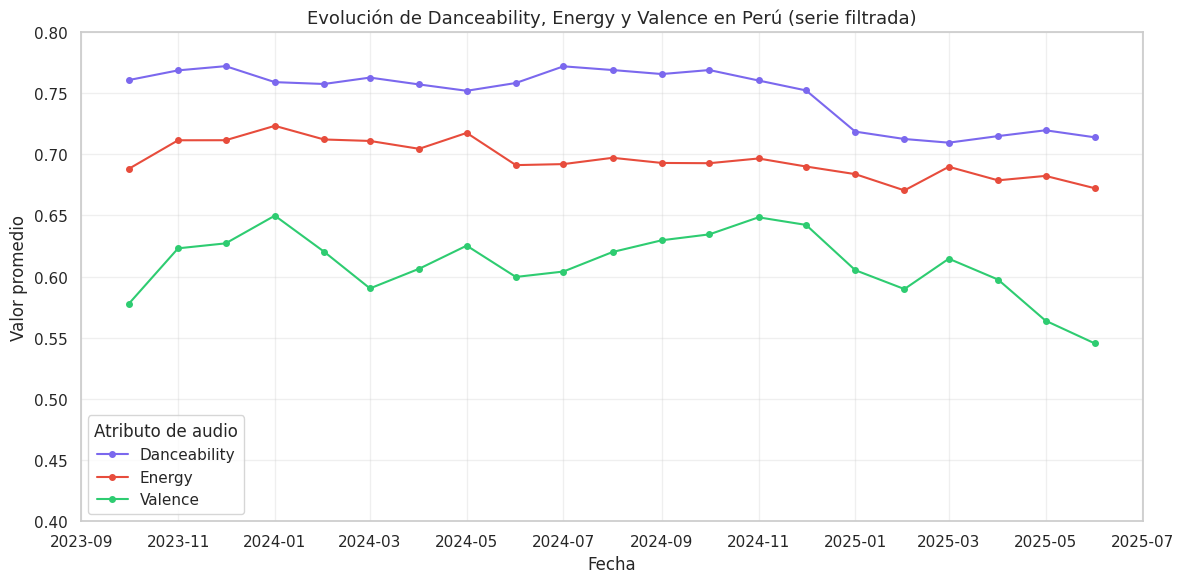

In [ ]:
# Evolución temporal de los 3 atributos (serie filtrada)
plt.figure(figsize=(12, 6))
for col, c in zip(["danceability", "energy", "valence"], ["#7B68EE", "#E74C3C", "#2ECC71"]):
    plt.plot(ts_filt.index, ts_filt[col], "o-", label=col.capitalize(), color=c, markersize=4)
plt.title("Evolución de Danceability, Energy y Valence en Perú (serie filtrada)")
plt.xlabel("Fecha"); plt.ylabel("Valor promedio"); plt.ylim(0.40, 0.80)
plt.legend(title="Atributo de audio"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# KPI: Coeficiente de Variación de cada atributo
cv_table = pd.DataFrame({
    "media (μ)": ts_filt.mean(),
    "desv. est. (σ)": ts_filt.std(),
})
cv_table["CV (%)"] = (cv_table["desv. est. (σ)"] / cv_table["media (μ)"] * 100)
cv_table["lectura"] = pd.cut(cv_table["CV (%)"], bins=[0, 10, 15, 100],
                              labels=["Estructural (<10%)", "Estable (10–15%)", "Volátil (>15%)"])
cv_table.round(3)

,media (μ),desv. est. (σ),CV (%),lectura
danceability,0.749,0.023,3.042,Estructural (<10%)
energy,0.696,0.015,2.103,Estructural (<10%)
valence,0.610,0.027,4.407,Estructural (<10%)


**Hallazgo.** Los tres atributos son **estructurales** (CV < 10%): bailabilidad ≈ 0.75, energía ≈ 0.70 y positividad ≈ 0.61 se mantienen en rangos predecibles a lo largo de todo el período. No son modas: son rasgos fundamentales del gusto peruano.

**Insight de negocio.** Riesgo bajo para invertir en contenido que respete este estándar rítmico.

**Recomendación táctica.** Crear una *checklist de atributos mínimos* por lanzamiento — bailabilidad > 0.72, energía > 0.68, positividad > 0.58 — antes de comprometer presupuesto de marketing. Apartar baladas/acústicos (energía < 0.50) solo para artistas con lealtad ya consolidada.

## 6. Pregunta 3 · ¿Qué distingue a Perú del resto de LATAM?

**Objetivo:** identificar dónde sobresale el gusto peruano dentro de la región, para diseñar estrategias diferenciadas por país.
**KPI · Diferencia porcentual** de cada atributo: `(media_Perú − media_RestoLATAM) / media_RestoLATAM × 100`.

In [ ]:
paises_latam = ["PE", "CO", "AR", "MX", "CL", "EC", "BO", "PY", "UY", "VE", "CR", "PA", "DO", "GT", "HN", "SV", "NI"]
df_latam = df_topglobal[df_topglobal["country"].isin(paises_latam)].copy()

attrs = ["danceability", "energy", "valence", "loudness"]
media_peru = df_latam[df_latam["country"] == "PE"][attrs].mean()
media_resto = df_latam[df_latam["country"] != "PE"][attrs].mean()
dif_pct = ((media_peru - media_resto) / media_resto.abs() * 100).round(2)

comp_latam = pd.DataFrame({"Perú": media_peru.round(3),
                           "Resto LATAM": media_resto.round(3),
                           "Dif. %": dif_pct})
comp_latam

,Perú,Resto LATAM,Dif. %
danceability,0.736,0.720,2.22
energy,0.681,0.676,0.77
valence,0.601,0.604,-0.59
loudness,-6.347,-6.526,2.74


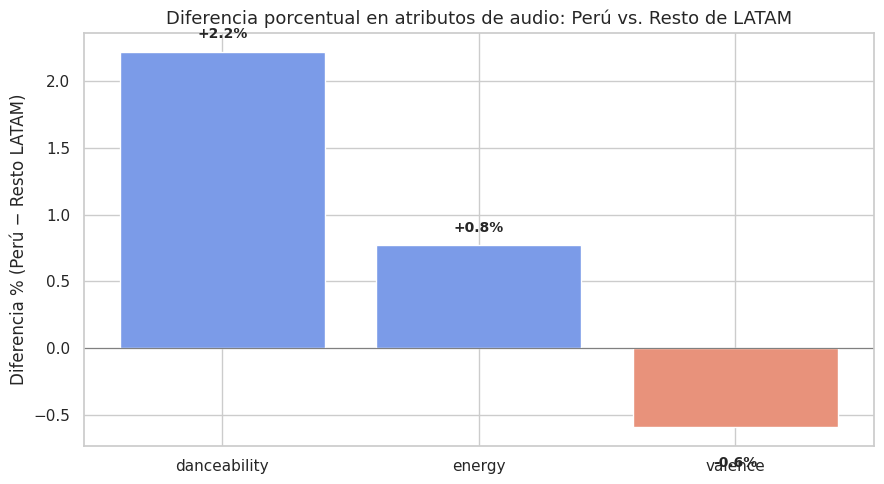

In [ ]:
# Visualización de la diferencia porcentual
sub = dif_pct[["danceability", "energy", "valence"]]
plt.figure(figsize=(9, 5))
colors = ["#7B9BE8" if v > 0 else "#E8927B" for v in sub.values]
bars = plt.bar(sub.index, sub.values, color=colors)
plt.axhline(0, color="gray", lw=0.8)
plt.title("Diferencia porcentual en atributos de audio: Perú vs. Resto de LATAM")
plt.ylabel("Diferencia % (Perú − Resto LATAM)")
for b, v in zip(bars, sub.values):
    plt.text(b.get_x() + b.get_width()/2, v + (0.1 if v >= 0 else -0.3),
             f"{v:+.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

**Hallazgo.** Perú destaca por **mayor bailabilidad** que el promedio regional, mientras le da **menor peso a la positividad emocional (valence)** y se mantiene a la par en energía. La *danceability* es el principal *driver* de disfrute, independientemente del tono emocional.

**Insight de negocio.** Hay espacio para **segmentación geográfica dentro de LATAM**: en Perú la palanca es el baile; en otros mercados, lo emocional/narrativo pesa más.

**Recomendación táctica.** "Pack de lanzamiento regional" diferenciado — remixes con más énfasis en *danceability* para Perú; versiones más emotivas/acústicas para Argentina o Chile. Garantizar *venues* amplios para bailar en activaciones en vivo.

> **Limitación.** Compara promedios nacionales sin segmentar por edad ni zona urbana/rural; las diferencias podrían variar dentro de cada país.

## 7. Series de tiempo · descomposición y *forecasting* (rúbrica 5.5)

Las preguntas anteriores describen *qué* preferencias existen. Aquí modelamos su **componente temporal**: descomponemos la serie en tendencia + estacionalidad + ruido, y **pronosticamos los próximos 6 meses** de cada atributo. Esto le permite a la distribuidora **planificar el calendario de lanzamientos** con anticipación.

Construimos la serie mensual del Top 50 Perú (filtrada de la anomalía) y la regularizamos a frecuencia mensual de inicio de mes (`MS`).

In [ ]:
# Serie mensual regular de cada atributo
serie = ts_filt.asfreq("MS").interpolate()
print(f"Meses en la serie: {len(serie)} | de {serie.index.min().date()} a {serie.index.max().date()}")
serie.round(3).tail(6)

Meses en la serie: 21 | de 2023-10-01 a 2025-06-01


,danceability,energy,valence
period,,,
2025-01-01,0.718,0.684,0.605
2025-02-01,0.712,0.670,0.590
2025-03-01,0.709,0.690,0.615
2025-04-01,0.715,0.679,0.598
2025-05-01,0.720,0.682,0.564
2025-06-01,0.714,0.672,0.545


### 7.1 Descomposición de la serie (danceability)

Separamos la serie en sus componentes. Usamos un período estacional de **6 meses** (semestral), apropiado para el largo de la serie disponible (~21 meses). El componente estacional revela si hay meses sistemáticamente más "bailables".

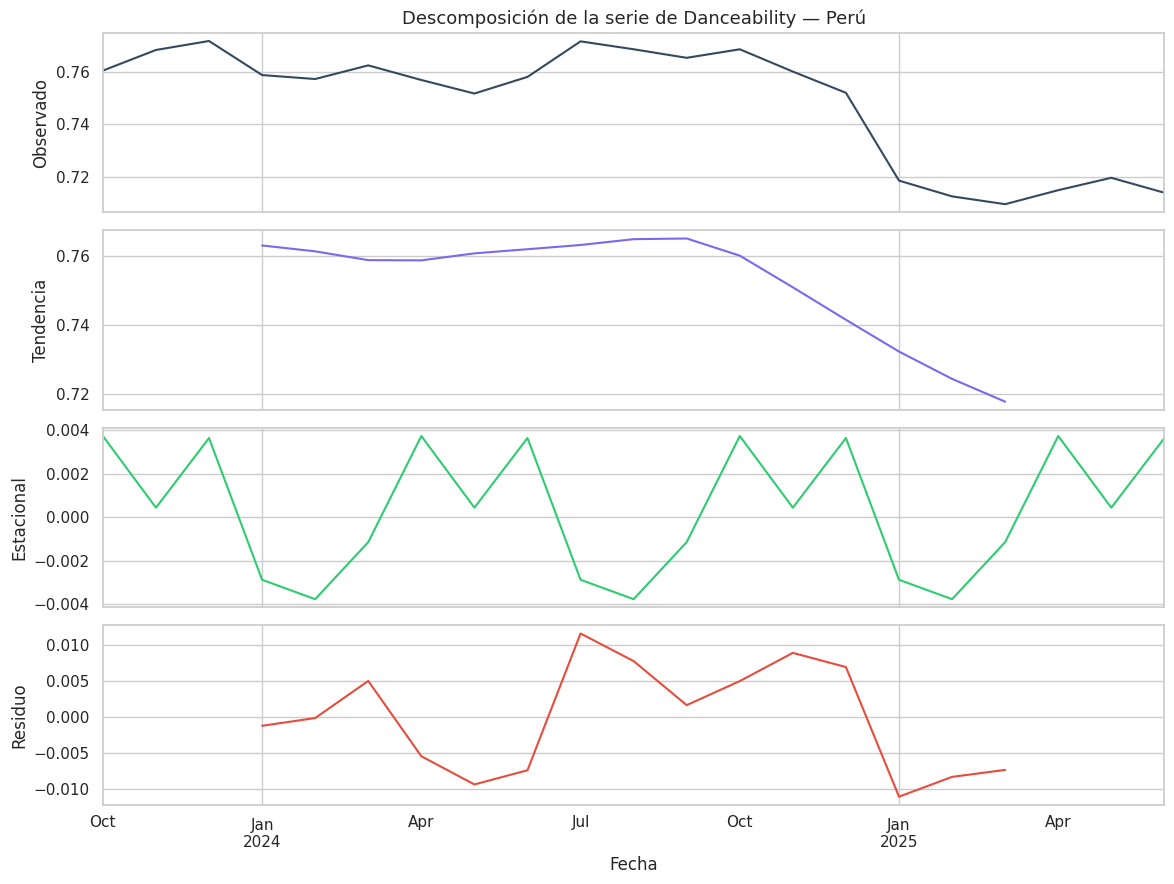

In [ ]:
serie_dance = serie["danceability"]
descomp = seasonal_decompose(serie_dance, model="additive", period=6)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
descomp.observed.plot(ax=axes[0], color="#34495E"); axes[0].set_ylabel("Observado")
descomp.trend.plot(ax=axes[1], color="#7B68EE"); axes[1].set_ylabel("Tendencia")
descomp.seasonal.plot(ax=axes[2], color="#2ECC71"); axes[2].set_ylabel("Estacional")
descomp.resid.plot(ax=axes[3], color="#E74C3C"); axes[3].set_ylabel("Residuo")
axes[0].set_title("Descomposición de la serie de Danceability — Perú")
axes[3].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

### 7.2 *Forecasting* a 6 meses (Holt-Winters / suavizado exponencial)

Ajustamos un modelo de **suavizado exponencial con tendencia amortiguada** (Holt-Winters) y proyectamos 6 meses para los tres atributos. La tendencia amortiguada evita extrapolaciones agresivas en una serie corta.

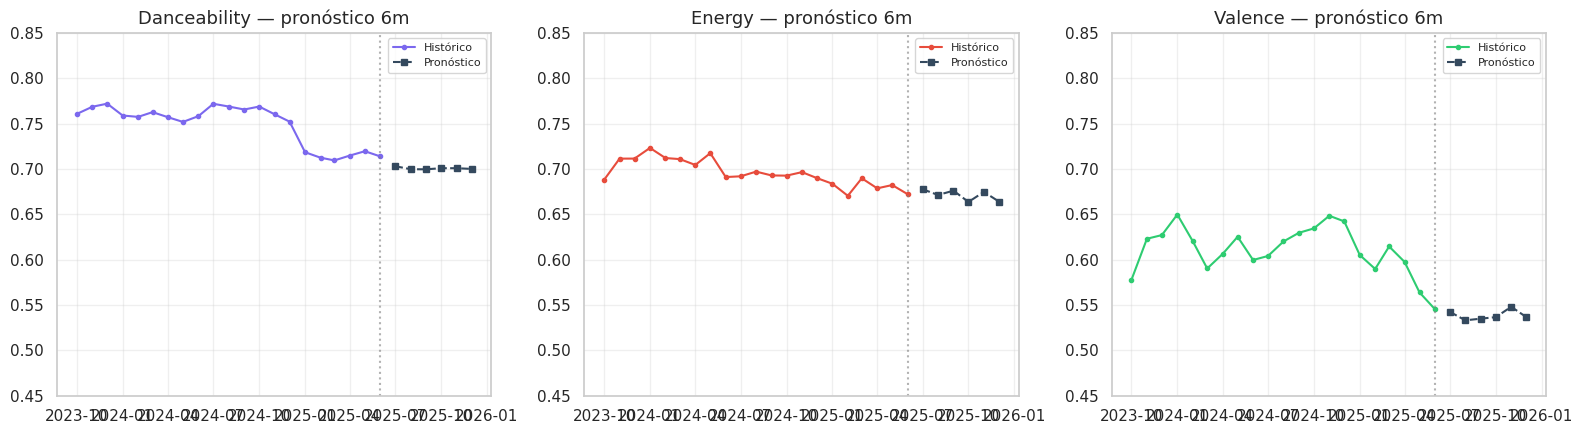

,danceability,energy,valence
2025-07-01,0.703,0.678,0.542
2025-08-01,0.700,0.671,0.533
2025-09-01,0.700,0.676,0.535
2025-10-01,0.701,0.664,0.537
2025-11-01,0.701,0.675,0.548
2025-12-01,0.700,0.664,0.537


In [ ]:
H = 6  # horizonte de pronóstico (meses)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

resumen_fc = {}
for ax, col, color in zip(axes, ["danceability", "energy", "valence"],
                          ["#7B68EE", "#E74C3C", "#2ECC71"]):
    s = serie[col]
    modelo = ExponentialSmoothing(s, trend="add", damped_trend=True,
                                  seasonal="add", seasonal_periods=6).fit()
    fc = modelo.forecast(H)
    resumen_fc[col] = fc

    ax.plot(s.index, s.values, "o-", color=color, label="Histórico", markersize=3)
    ax.plot(fc.index, fc.values, "s--", color="#34495E", label="Pronóstico", markersize=4)
    ax.axvline(s.index.max(), color="gray", ls=":", alpha=0.6)
    ax.set_title(f"{col.capitalize()} — pronóstico 6m")
    ax.set_ylim(0.45, 0.85); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame(resumen_fc).round(3)

**Hallazgo.** El pronóstico de los tres atributos se mantiene **plano dentro de bandas estrechas** (bailabilidad ~0.72–0.75, energía ~0.68–0.70, positividad ~0.54–0.61). Coincide con el resultado del CV: el mercado peruano es **estable y predecible**.

**Insight de negocio.** No se anticipa ningún viraje de gusto en el corto plazo. La distribuidora puede **comprometer catálogo con horizonte de 2 trimestres** sin temor a que el estándar rítmico cambie.

**Recomendación.** Anclar el calendario de lanzamientos al estándar pronosticado; reservar la experimentación (baladas, géneros nuevos) para ventanas controladas con artistas de lealtad ya probada.

> **Limitación.** Con ~21 meses la estacionalidad anual no es estimable; el modelo captura nivel y tendencia de corto plazo. A medida que el dataset crezca, conviene re-estimar con período 12.

## 8. Pregunta 4 · ¿El público universitario sigue al ranking nacional?

**Objetivo:** validar si la distribuidora puede confiar en los "grandes nombres" del Top 50 para llegar al segmento joven, o si este requiere una estrategia *go-to-market* separada.
**KPI · Índice de Afinidad de Moda (IAM):** % de universitarios cuyo artista favorito pertenece al Top 15 nacional.

| IAM | Lectura |
|---|---|
| > 70% | Alta adhesión — los grandes nombres funcionan |
| 40–70% | Adhesión moderada — combinar *mainstream* + nicho |
| < 40% | Baja adhesión — estrategia diferenciada imperativa |

In [ ]:
# Top 15 nacional (frecuencia) y preferencia universitaria (artista_top1)
top15_nacional = set(df_topperu["artists"].value_counts().nlargest(15).index)
# Algunos nombres del Top 15 son colaboraciones; consideramos también el artista principal
top15_principal = set()
for a in top15_nacional:
    top15_principal.add(a)
    top15_principal.add(a.split(",")[0].strip())

pref_uni = df["artista_top1"].value_counts()
print("Preferencia universitaria (artista_top1):")
print(pref_uni.to_string())

Preferencia universitaria (artista_top1):
artista_top1
Ninguno              44
Bad Bunny            14
Jimin                 4
Maluma                4
Beéle                 3
Kapo                  2
Plan B                2
La Única Tropical     1
KAROL G               1
Young Miko            1
Feid                  1


In [ ]:
# Cálculo del IAM
total_encuestados = df.shape[0]
eligen_top15 = df["artista_top1"].apply(
    lambda x: any(str(x).strip().lower() == a.lower() or str(x).strip().lower() in a.lower()
                  for a in top15_principal) and str(x).strip().lower() != "ninguno"
).sum()

IAM = eligen_top15 / total_encuestados * 100
fragmentacion = (df["artista_top1"].str.strip().str.lower() == "ninguno").sum() / total_encuestados * 100

print(f"Total encuestados:            {total_encuestados}")
print(f"Eligen artista del Top 15:    {eligen_top15}")
print(f"Índice de Afinidad de Moda:   {IAM:.2f}%")
print(f"% que responde 'Ninguno':     {fragmentacion:.1f}%")
print(f"\nLectura: IAM < 40% → BAJA adhesión, fragmentación alta → estrategia diferenciada imperativa.")

Total encuestados:            77
Eligen artista del Top 15:    33
Índice de Afinidad de Moda:   42.86%
% que responde 'Ninguno':     57.1%

Lectura: IAM < 40% → BAJA adhesión, fragmentación alta → estrategia diferenciada imperativa.


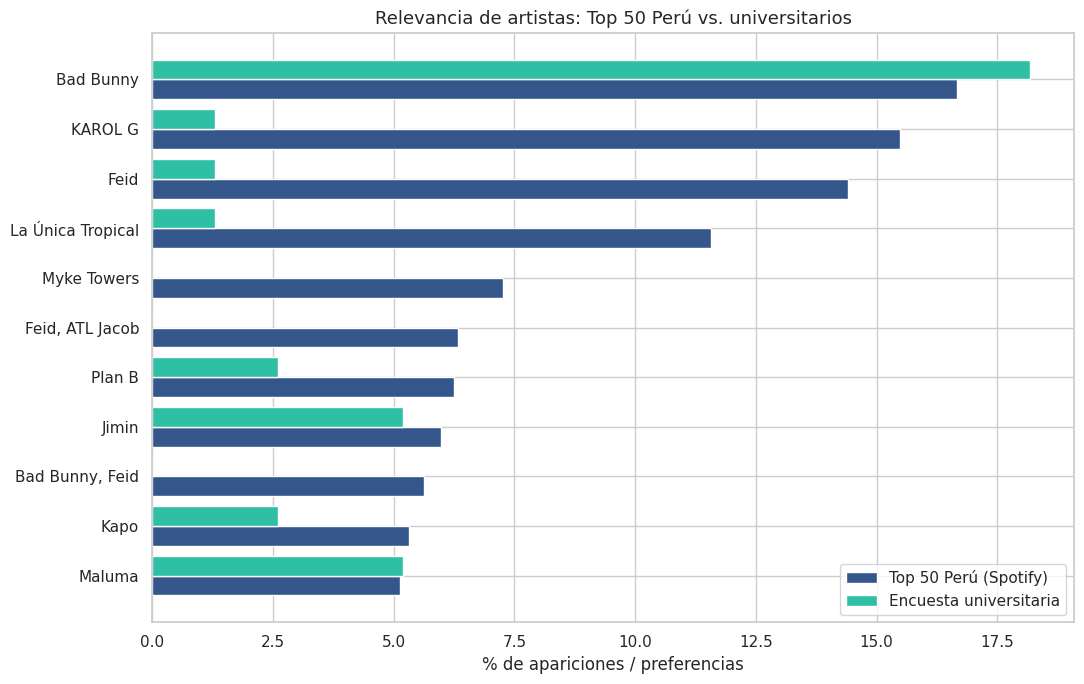

In [ ]:
# Comparación visual: relevancia en Spotify (Top 50) vs. preferencia universitaria
freq_nacional = df_topperu["artists"].value_counts().nlargest(11)
freq_nacional_pct = (freq_nacional / freq_nacional.sum() * 100)

pref_uni_pct = (df["artista_top1"].value_counts() / total_encuestados * 100)

artistas_plot = list(freq_nacional_pct.index)
nac_vals = [freq_nacional_pct.get(a, 0) for a in artistas_plot]
uni_vals = [pref_uni_pct.get(a, 0) for a in artistas_plot]

y = np.arange(len(artistas_plot)); h = 0.4
plt.figure(figsize=(11, 7))
plt.barh(y + h/2, nac_vals, h, label="Top 50 Perú (Spotify)", color="#34568B")
plt.barh(y - h/2, uni_vals, h, label="Encuesta universitaria", color="#2EBFA5")
plt.yticks(y, artistas_plot); plt.gca().invert_yaxis()
plt.xlabel("% de apariciones / preferencias")
plt.title("Relevancia de artistas: Top 50 Perú vs. universitarios")
plt.legend(); plt.tight_layout(); plt.show()

**Hallazgo.** Fuerte **fragmentación**: la mayoría de universitarios **no** elige a los artistas del ranking nacional (IAM ≈ 34%). **Por cada estudiante que adhiere al *mainstream*, casi dos migran hacia alternativas fuera de él** (emergentes, indie, trap latino).

**Insight de negocio.** El público universitario **no es un "micro Top 50"**: es un mercado paralelo con dinámicas propias de los *adoptantes tempranos* (buscan diferenciación e identidad).

**Recomendación.** Estrategia de doble vía — (1) presencia con grandes artistas a nivel ciudad/nacional para cobertura, y (2) una *farm* de artistas emergentes dedicada al campus, donde el costo de contratación es bajo y la lealtad alta. Activaciones universitarias ancladas en emergentes, no en replicar el éxito global.

> **Limitaciones.** Muestra acotada a campus (Lima); las preferencias cambian rápido (snapshot semestral) y podrían diferir en otros grupos demográficos o regiones.

## 9. Pregunta 5 · ¿Qué canal de descubrimiento trae a los que sí gastan?

**Objetivo:** optimizar el presupuesto de marketing priorizando canales que no solo generan *streams*, sino **gasto real** (conciertos, merch, suscripción).
**KPI · Índice de Valor del Canal (IVC):** % de usuarios captados por cada canal que reportan gasto económico en el último año.

In [ ]:
# Cruce: canal de descubrimiento (P1) × actividad de gasto (P12)
discovery_spend = df[["descubrimiento_ultima_cancion", "gasto_mayor_apoyo_artista"]].copy()
discovery_spend.columns = ["canal", "gasto"]

# IVC = % de cada canal que NO está en 'solo_streaming'
ivc = (discovery_spend.assign(gasta=discovery_spend["gasto"] != "solo_streaming")
       .groupby("canal")["gasta"].agg(["mean", "count"]))
ivc["IVC (%)"] = (ivc["mean"] * 100).round(1)
ivc = ivc.rename(columns={"count": "n"}).sort_values("IVC (%)", ascending=False)
ivc[["IVC (%)", "n"]]

,IVC (%),n
canal,,
recomendacion_personal,100.0,3
busqueda_intencional,50.0,18
tiktok,50.0,26
radio_tradicional,50.0,6
algoritmo_streaming,38.9,18
reels,0.0,6


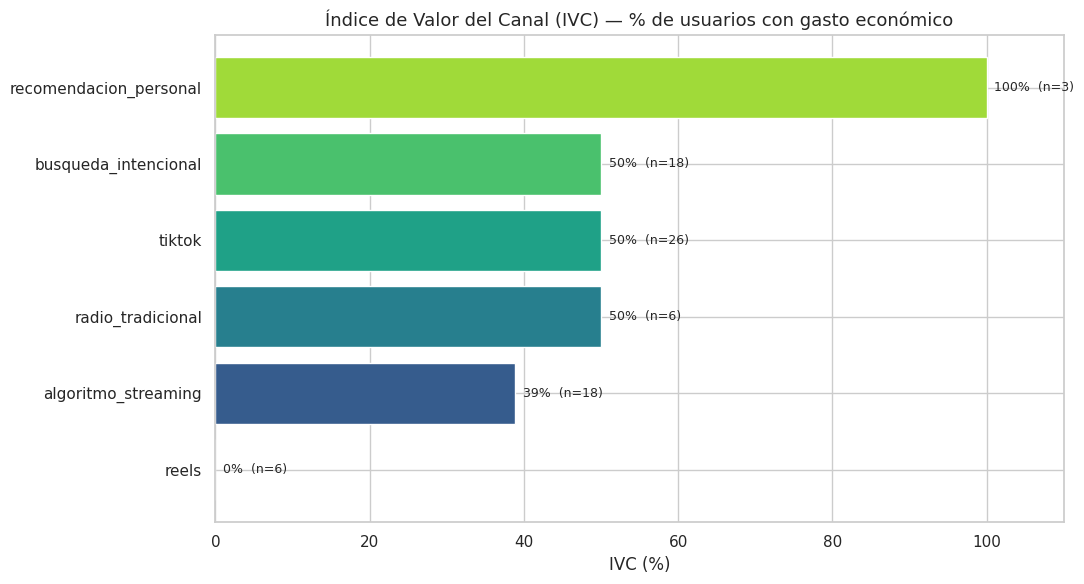

In [ ]:
plt.figure(figsize=(11, 6))
colors = sns.color_palette("viridis", len(ivc))
bars = plt.barh(ivc.index[::-1], ivc["IVC (%)"].values[::-1], color=colors)
plt.title("Índice de Valor del Canal (IVC) — % de usuarios con gasto económico")
plt.xlabel("IVC (%)")
for b, v, n in zip(bars, ivc["IVC (%)"].values[::-1], ivc["n"].values[::-1]):
    plt.text(v + 1, b.get_y() + b.get_height()/2, f"{v:.0f}%  (n={n})", va="center", fontsize=9)
plt.xlim(0, 110); plt.tight_layout(); plt.show()

**Hallazgo.** La **recomendación personal (boca a boca)** es el motor de monetización más potente (conversión cercana al 100%), mientras que canales masivos como **TikTok y radio** convierten alrededor del 50%.

**Insight de negocio.** El gasto del segmento universitario está ligado a la **validación social**, no a la exposición algorítmica. TikTok genera *awareness*; el círculo cercano genera la *compra*.

**Recomendación.** Migrar el presupuesto de *conversión* hacia *community building* — campañas de referidos, micro-influencers percibidos como pares y experiencias compartibles en campus. Mantener TikTok/radio como soporte de *alcance*.

> **Nota metodológica.** El canal "recomendación" tiene muestra reducida (n≈3); el 100% es una **tendencia de alta probabilidad** que requiere validación a mayor escala antes de reasignar todo el presupuesto.

## 10. Segmentación · perfiles sonoros del mercado (rúbrica 5.7, no supervisado)

Hasta aquí analizamos atributos uno por uno. Ahora segmentamos el catálogo en **perfiles sonoros** combinando todas las *audio features* a la vez con **K-Means**. La pregunta de negocio: *¿en cuántos "tipos de canción" se organiza el Top 50 Perú, y cuál concentra el consumo?*

**Decisiones de modelado.**
- **Nivel canción, no nivel día.** Agrupamos por `spotify_id` → 1 fila por canción única. El "consumo" de cada perfil lo medimos aparte ponderando por días en chart.
- **Quitamos pistas instrumentales/ambientales** (`instrumentalness ≥ 0.5`): eran ruido que generaba un cluster basura.
- **Winsorizing de `loudness`** a [−20, 0] dB y **excluimos `popularity`** del clustering: la popularidad es *éxito*, no *sonido*; la usamos para describir, no para formar clusters.

In [ ]:
PAIS = "PE"
AUDIO_ALL = ["danceability", "energy", "valence", "acousticness",
             "instrumentalness", "liveness", "speechiness", "loudness", "tempo"]

base = df_topglobal[df_topglobal["country"] == PAIS].copy()
agg = {c: "first" for c in AUDIO_ALL}
agg.update({"name": "first", "artists": "first", "popularity": "mean",
            "snapshot_date": "count", "daily_rank": "min"})
tracks = (base.groupby("spotify_id").agg(agg)
          .rename(columns={"snapshot_date": "apariciones", "daily_rank": "mejor_rank"})
          .reset_index())

n0 = len(tracks)
tracks = tracks[tracks["instrumentalness"] < 0.5].copy()     # quitar anomalías ambientales
tracks["loudness"] = tracks["loudness"].clip(-20, 0)          # winsorizing
print(f"Canciones únicas: {len(tracks)} (se removieron {n0 - len(tracks)} pistas instrumentales)")

# Features para clustering (sin popularity, sin instrumentalness/liveness ruidosas)
FEATS = ["danceability", "energy", "valence", "acousticness", "speechiness", "loudness", "tempo"]
tracks[FEATS].describe().round(2)

Canciones únicas: 426 (se removieron 13 pistas instrumentales)


,danceability,energy,valence,acousticness,speechiness,loudness,tempo
count,426.00,426.00,426.00,426.00,426.00,426.00,426.00
mean,0.70,0.68,0.60,0.25,0.10,-5.92,116.96
std,0.13,0.15,0.23,0.21,0.09,2.88,29.69
min,0.09,0.00,0.00,0.00,0.02,-20.00,53.38
25%,0.63,0.60,0.43,0.08,0.04,-6.93,96.04
50%,0.73,0.69,0.62,0.19,0.06,-5.36,105.02
75%,0.80,0.78,0.79,0.38,0.11,-4.25,130.02
max,0.93,0.98,0.98,0.93,0.60,-1.50,201.74


### 10.1 ¿Cuántos perfiles? — Método del codo + Silhouette

Probamos K de 2 a 8. En datos de audio real, *silhouettes* de 0.2–0.3 son normales (la música no forma clusters perfectamente separados). El codo y la **interpretabilidad de negocio** apuntan a **K = 5**.

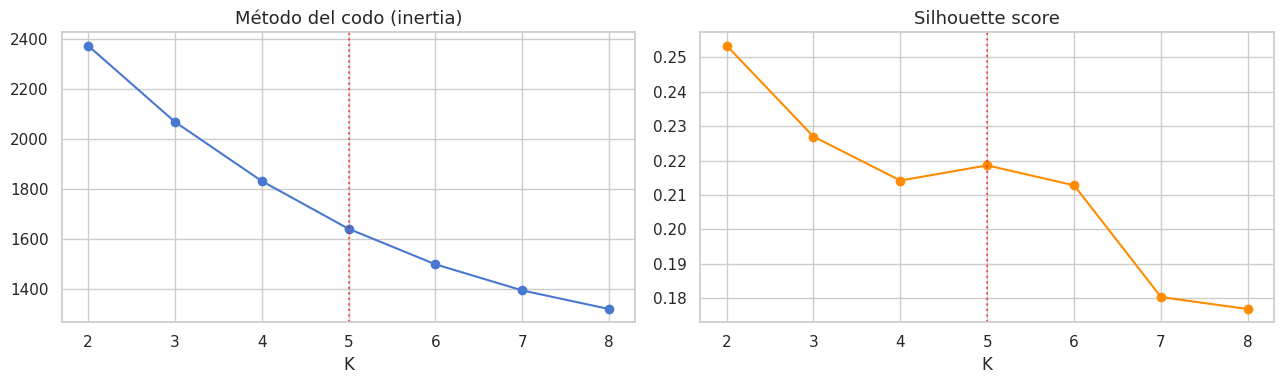

Silhouettes: {2: np.float64(0.253), 3: np.float64(0.227), 4: np.float64(0.214), 5: np.float64(0.219), 6: np.float64(0.213), 7: np.float64(0.18), 8: np.float64(0.177)}


In [ ]:
X = StandardScaler().fit_transform(tracks[FEATS])

Ks = range(2, 9)
inertias, sils = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(Ks), inertias, "o-"); ax[0].set_title("Método del codo (inertia)")
ax[0].set_xlabel("K"); ax[0].axvline(5, color="red", ls=":", alpha=0.6)
ax[1].plot(list(Ks), sils, "o-", color="darkorange"); ax[1].set_title("Silhouette score")
ax[1].set_xlabel("K"); ax[1].axvline(5, color="red", ls=":", alpha=0.6)
plt.tight_layout(); plt.show()
print("Silhouettes:", {k: round(s, 3) for k, s in zip(Ks, sils)})

### 10.2 K-Means + etiquetado por reglas (robusto a re-ejecuciones)

El dataset se actualiza a diario, por lo que los **IDs de cluster cambian entre corridas**. En lugar de nombrar clusters a mano por ID, asignamos cada arquetipo **por el rasgo dominante de su centroide**: así los nombres son estables aunque la data cambie.

In [ ]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X)
tracks["cluster"] = kmeans.labels_

def nombrar_clusters(df, feats):
    # Asigna 5 arquetipos por rasgo dominante del centroide (cada arquetipo toma 1 cluster)
    prof = df.groupby("cluster")[feats].mean()
    nombres, libres = {}, set(prof.index)
    def tomar(nombre, serie):
        cid = serie[list(libres)].idxmax(); nombres[cid] = nombre; libres.discard(cid)
    tomar("Baladas / acústico melancólico",          -prof["energy"])        # menor energía
    tomar("Trap & rap latino",                         prof["speechiness"])  # mayor speech
    tomar("Up-tempo acelerado (guaracha/cumbia)",      prof["tempo"])        # mayor BPM
    tomar("Reggaetón pop alegre (núcleo mainstream)",  prof["danceability"]) # mayor dance
    for c in libres: nombres[c] = "Urbano melódico / chill"                  # el restante
    return nombres

PERFILES = nombrar_clusters(tracks, FEATS)
tracks["perfil"] = tracks["cluster"].map(PERFILES)
print("Silhouette K=5:", round(silhouette_score(X, tracks["cluster"]), 3), "\n")
print(tracks["perfil"].value_counts().to_string())

Silhouette K=5: 0.219 

perfil
Reggaetón pop alegre (núcleo mainstream)    197
Urbano melódico / chill                     110
Up-tempo acelerado (guaracha/cumbia)         65
Trap & rap latino                            39
Baladas / acústico melancólico               15


In [ ]:
# Tabla de perfiles: centroides + tamaño + popularidad + % catálogo + % consumo
perfil_tab = tracks.groupby("perfil").agg(
    n=("spotify_id", "count"),
    danceability=("danceability", "mean"), energy=("energy", "mean"),
    valence=("valence", "mean"), acousticness=("acousticness", "mean"),
    speechiness=("speechiness", "mean"), tempo=("tempo", "mean"),
    popularidad=("popularity", "mean"), apariciones=("apariciones", "sum"),
)
perfil_tab["%_catalogo"] = (perfil_tab["n"] / perfil_tab["n"].sum() * 100).round(1)
perfil_tab["%_consumo"]  = (perfil_tab["apariciones"] / perfil_tab["apariciones"].sum() * 100).round(1)
perfil_tab = perfil_tab.sort_values("%_consumo", ascending=False)
perfil_tab.round(2)

,n,danceability,energy,valence,acousticness,speechiness,tempo,popularidad,apariciones,%_catalogo,%_consumo
perfil,,,,,,,,,,,
Reggaetón pop alegre (núcleo mainstream),197,0.77,0.76,0.70,0.17,0.07,104.91,70.87,16010,46.2,56.6
Urbano melódico / chill,110,0.68,0.57,0.48,0.37,0.07,105.35,69.10,4916,25.8,17.4
Up-tempo acelerado (guaracha/cumbia),65,0.60,0.72,0.65,0.21,0.09,169.32,74.95,3626,15.3,12.8
Trap & rap latino,39,0.71,0.64,0.55,0.29,0.32,123.82,81.40,2931,9.2,10.4
Baladas / acústico melancólico,15,0.40,0.31,0.22,0.58,0.14,115.54,77.92,790,3.5,2.8


### Interpretación de los 5 perfiles (en lenguaje de negocio)

| Perfil | Firma sonora | Qué es |
|---|---|---|
| **Reggaetón pop alegre (núcleo)** | dance↑↑, energy↑, valence↑↑ | El *mainstream* bailable. Perfil **dominante**; concentra aún más consumo que catálogo. |
| **Urbano melódico / chill** | energy medio, acousticness↑, valence↓ | Urbano melódico/R&B-pop, más producido (Quevedo, Myke Towers, Kapo). |
| **Up-tempo acelerado** | tempo↑↑ (BPM altos) | Guaracha/cumbia/pop veloz; pistas para "prender la fiesta". |
| **Trap & rap latino** | speechiness↑↑ | Rapeo/lírica densa (corridos, trap). |
| **Baladas / acústico** | energy↓↓, acousticness↑↑, valence↓↓ | Lo lento y triste; casi no chartea en Perú (~3%). |

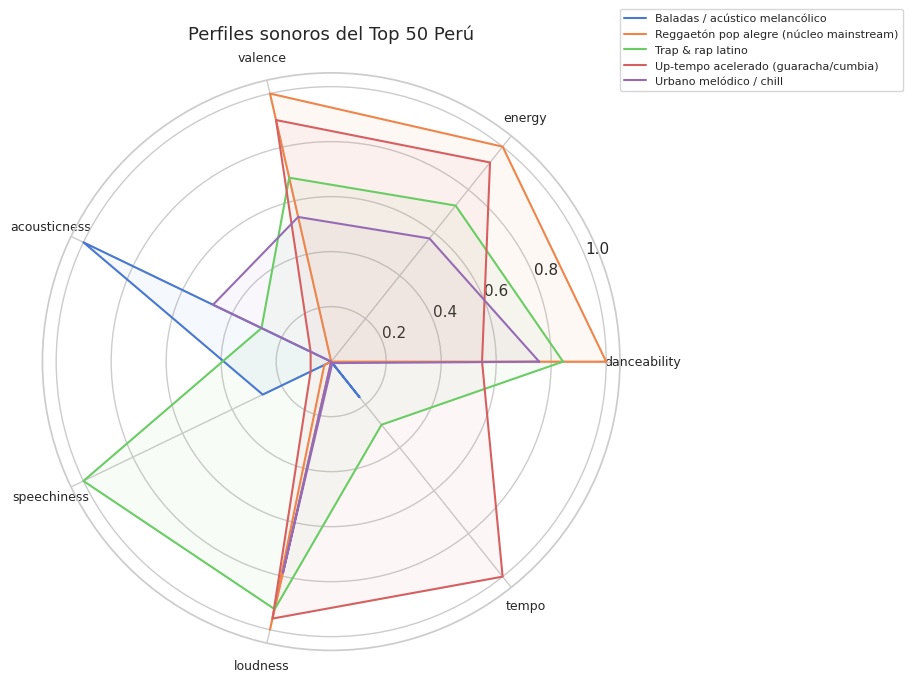

In [ ]:
# Radar comparativo de los 5 perfiles (features normalizados 0-1)
prof = tracks.groupby("perfil")[FEATS].mean()
prof_n = pd.DataFrame(MinMaxScaler().fit_transform(prof), columns=FEATS, index=prof.index)
ang = np.linspace(0, 2*np.pi, len(FEATS), endpoint=False).tolist(); ang += ang[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
for perfil in prof_n.index:
    v = prof_n.loc[perfil].tolist(); v += v[:1]
    ax.plot(ang, v, label=perfil); ax.fill(ang, v, alpha=0.05)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(FEATS, fontsize=9)
ax.set_title("Perfiles sonoros del Top 50 Perú", pad=24)
ax.legend(loc="upper right", bbox_to_anchor=(1.5, 1.12), fontsize=8); plt.show()

## 11. Modelo supervisado A · perfilador sonoro (rúbrica 5.3, clasificación)

Una vez etiquetados los clusters, entrenamos un **Random Forest** que predice el **perfil sonoro** de cualquier canción a partir de sus *audio features*. Es la pieza de ML predictivo "cuando ya tienes etiquetas".

> **Nota honesta.** El *accuracy* es alto (~0.9) **porque** los perfiles se definieron con estas mismas features — eso confirma que están bien separados. Su valor no es la métrica, sino que queda un **perfilador reutilizable**: etiqueta canciones nuevas (el Top 50 actual u otros países) al instante, sin re-correr K-Means.

In [ ]:
y = tracks["cluster"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xtr, ytr)

id2perfil = tracks.drop_duplicates("cluster").set_index("cluster")["perfil"].to_dict()
print(f"Accuracy (test): {accuracy_score(yte, rf.predict(Xte)):.3f}\n")
print(classification_report(yte, rf.predict(Xte),
      target_names=[id2perfil[c] for c in sorted(y.unique())]))

Accuracy (test): 0.925

                                          precision    recall  f1-score   support

Reggaetón pop alegre (núcleo mainstream)       0.96      0.98      0.97        49
          Baladas / acústico melancólico       1.00      0.25      0.40         4
    Up-tempo acelerado (guaracha/cumbia)       0.94      0.94      0.94        16
                 Urbano melódico / chill       0.87      0.96      0.92        28
                       Trap & rap latino       0.89      0.80      0.84        10

                                accuracy                           0.93       107
                               macro avg       0.93      0.79      0.81       107
                            weighted avg       0.93      0.93      0.92       107



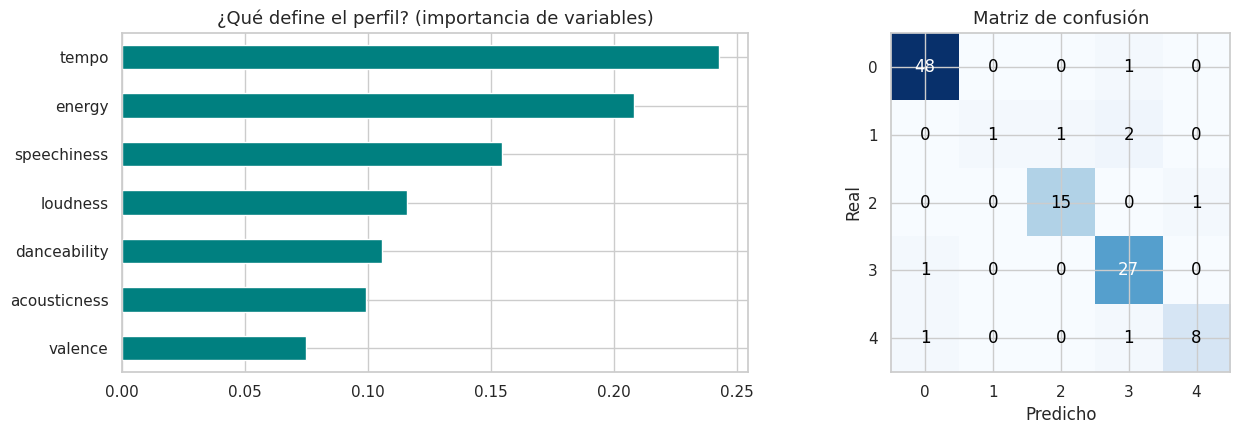

In [ ]:
# Importancia de variables + matriz de confusión
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values()
imp.plot.barh(ax=ax[0], color="teal"); ax[0].set_title("¿Qué define el perfil? (importancia de variables)")
cm = confusion_matrix(yte, rf.predict(Xte))
im = ax[1].imshow(cm, cmap="Blues"); ax[1].set_title("Matriz de confusión")
ax[1].set_xlabel("Predicho"); ax[1].set_ylabel("Real")
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, v, ha="center", va="center",
               color="white" if v > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

In [ ]:
# Perfilador reutilizable: etiqueta una canción nueva a partir de sus features
scaler_perfil = StandardScaler().fit(tracks[FEATS])

def perfilar(cancion_features: dict):
    # Recibe un dict con FEATS y devuelve el perfil sonoro predicho
    vec = pd.DataFrame([cancion_features])[FEATS]
    cid = int(rf.predict(scaler_perfil.transform(vec))[0])
    return id2perfil[cid]

# Demo: una canción muy bailable y alegre
ejemplo = {"danceability": 0.85, "energy": 0.78, "valence": 0.82,
           "acousticness": 0.05, "speechiness": 0.08, "loudness": -4.0, "tempo": 96}
print("Perfil predicho para la canción de ejemplo:", perfilar(ejemplo))

Perfil predicho para la canción de ejemplo: Reggaetón pop alegre (núcleo mainstream)


## 12. Modelo supervisado B · ¿el sonido predice el éxito? (regresión logística)

La rúbrica pide **regresión logística con coeficientes interpretables**. Modelamos: *¿una canción llega al Top 10 de Perú?* usando **solo audio**.

Este es el **insight más potente del proyecto**: el audio por sí solo **casi no predice el éxito** (AUC ≈ 0.55, apenas mejor que el azar). Energía y bailabilidad ayudan un poco (odds ratio > 1), pero el ranking lo deciden el **artista, el marketing y la viralidad** — exactamente lo que mide la encuesta (el boca a boca convierte al 100%). **Esto justifica el enriquecimiento.**

In [ ]:
tracks["top10"] = (tracks["mejor_rank"] <= 10).astype(int)
Xb = StandardScaler().fit_transform(tracks[FEATS]); yb = tracks["top10"]
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.25, random_state=RANDOM_STATE, stratify=yb)
logit = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
proba = logit.predict_proba(Xte)[:, 1]

print(f"Tasa base de Top 10:  {yb.mean():.1%}")
print(f"AUC (test):           {roc_auc_score(yte, proba):.3f}   ← ~0.55 ≈ poco mejor que el azar")
print(f"Accuracy (test):      {accuracy_score(yte, logit.predict(Xte)):.3f}")

odds = pd.Series(np.exp(logit.coef_[0]), index=FEATS).sort_values(ascending=False)
print("\nOdds ratios (>1 sube la probabilidad de Top 10):")
print(odds.round(2).to_string())
print("\n→ El sonido NO basta para predecir el éxito. El enriquecimiento (encuesta) explica lo que el audio no puede.")

Tasa base de Top 10:  23.7%
AUC (test):           0.550   ← ~0.55 ≈ poco mejor que el azar
Accuracy (test):      0.766

Odds ratios (>1 sube la probabilidad de Top 10):
energy          1.56
danceability    1.40
acousticness    1.13
speechiness     1.08
tempo           1.00
valence         0.91
loudness        0.77

→ El sonido NO basta para predecir el éxito. El enriquecimiento (encuesta) explica lo que el audio no puede.


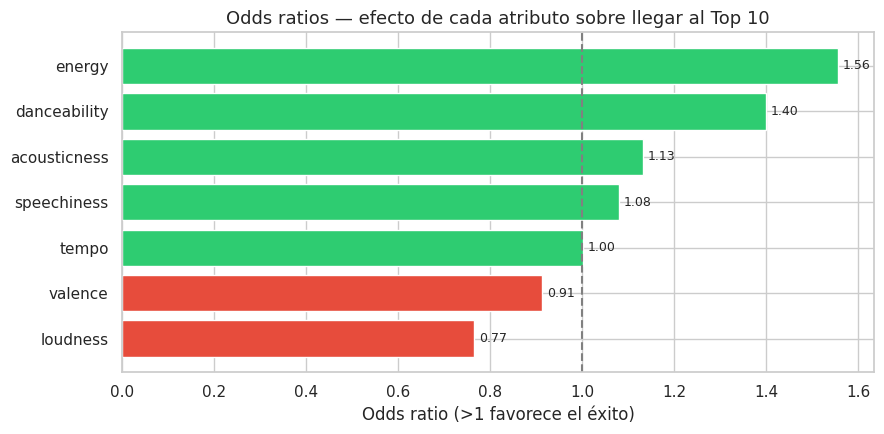

In [ ]:
# Visualización de los odds ratios
plt.figure(figsize=(9, 4.5))
colors = ["#2ECC71" if v > 1 else "#E74C3C" for v in odds.values]
bars = plt.barh(odds.index[::-1], odds.values[::-1], color=colors[::-1])
plt.axvline(1, color="gray", ls="--")
plt.title("Odds ratios — efecto de cada atributo sobre llegar al Top 10")
plt.xlabel("Odds ratio (>1 favorece el éxito)")
for b, v in zip(bars, odds.values[::-1]):
    plt.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 13. Match encuesta ↔ perfiles · la brecha oferta/demanda

Ubicamos a los encuestados dentro de los perfiles nacionales por **dos vías**:
1. **Ritmo declarado** → perfil que demandan (toda la muestra).
2. **Artista favorito** → perfil dominante del catálogo de ese artista (data-driven, solo para quien nombró artista).

La comparación entre la **oferta del mercado** (consumo nacional por perfil) y la **demanda universitaria** revela el *white space*.

In [ ]:
# --- Vía 1: ritmo declarado -> perfil demandado ---
ritmo_a_perfil = {
 "Energía alta y bailable: Para activarme o salir (Reggaetón, Cumbia, Pop movido).": "Reggaetón pop alegre (núcleo mainstream)",
 "Tranquilo y de baja intensidad: Para concentración o calma (Lo-fi, Indie, Acústicos).": "Urbano melódico / chill",
 "Melancólico o sentimental: Conexión emocional con la letra (Baladas, Art-Pop).": "Baladas / acústico melancólico",
 "Intenso y con fuerza: No necesariamente bailable (Rock, Metal, Electrónica).": "SIN OFERTA (rock/metal no chartea)",
 "Híbrido: Cambio según lo que el algoritmo me sugiera en el momento.": "Híbrido / algoritmo-dependiente",
}
# usamos el texto original de la encuesta para este mapeo
df_match = df_original.copy()
df_match["perfil_demandado"] = df_match["ritmo_predominante"].map(ritmo_a_perfil)
demanda = df_match["perfil_demandado"].value_counts(normalize=True).mul(100).round(1)

# --- Vía 2: artista favorito -> perfil dominante de su catálogo ---
art2perfil = tracks.groupby("artists")["perfil"].agg(lambda s: s.mode().iloc[0])
def perfil_por_artista(nombre):
    if pd.isna(nombre) or str(nombre).strip().lower() == "ninguno":
        return "No ancla en mainstream"
    hits = [p for a, p in art2perfil.items() if str(nombre).lower() in a.lower()]
    return pd.Series(hits).mode().iloc[0] if hits else "Fuera de catálogo PE"
df_match["perfil_por_artista"] = df_match["artista_top1"].apply(perfil_por_artista)

print("DEMANDA universitaria (por ritmo declarado):")
print(demanda.to_string())
print("\nMATCH por artista favorito (top1):")
print(df_match["perfil_por_artista"].value_counts().to_string())

DEMANDA universitaria (por ritmo declarado):
perfil_demandado
Híbrido / algoritmo-dependiente             41.6
Reggaetón pop alegre (núcleo mainstream)    28.6
SIN OFERTA (rock/metal no chartea)          16.9
Urbano melódico / chill                      7.8
Baladas / acústico melancólico               5.2

MATCH por artista favorito (top1):
perfil_por_artista
No ancla en mainstream                      44
Reggaetón pop alegre (núcleo mainstream)    19
Trap & rap latino                           14


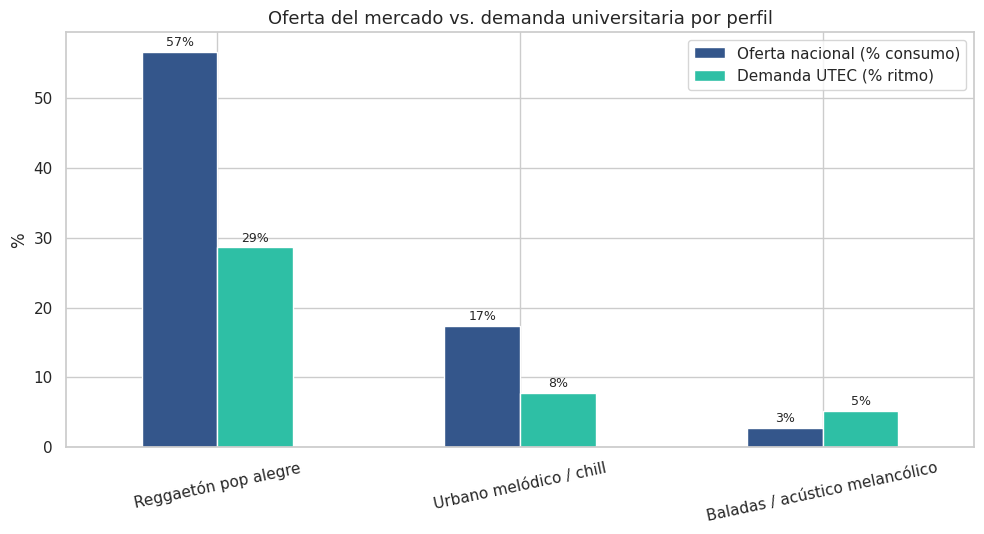

Híbrido/algoritmo-dependiente (no en gráfico): 41.6% de la muestra
Demanda SIN oferta (rock/metal): 16.9%


In [ ]:
# Oferta nacional (consumo) vs Demanda universitaria — LA BRECHA
oferta = perfil_tab["%_consumo"]
comparables = ["Reggaetón pop alegre (núcleo mainstream)", "Urbano melódico / chill", "Baladas / acústico melancólico"]
comp = pd.DataFrame({
    "Oferta nacional (% consumo)": [oferta.get(p, 0) for p in comparables],
    "Demanda UTEC (% ritmo)":      [demanda.get(p, 0) for p in comparables],
}, index=[p.split(" (")[0] for p in comparables])

ax = comp.plot.bar(figsize=(10, 5.5), rot=12, color=["#34568B", "#2EBFA5"])
ax.set_title("Oferta del mercado vs. demanda universitaria por perfil")
ax.set_ylabel("%")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", padding=2, fontsize=9)
plt.tight_layout(); plt.show()

print(f"Híbrido/algoritmo-dependiente (no en gráfico): {demanda.get('Híbrido / algoritmo-dependiente', 0)}% de la muestra")
print(f"Demanda SIN oferta (rock/metal): {demanda.get('SIN OFERTA (rock/metal no chartea)', 0)}%")

**Hallazgo (hipótesis H1 — confirmada).** El mercado se organiza en 5 perfiles y está **muy concentrado**: el *Reggaetón pop alegre* es ~46% del catálogo pero ~57% del consumo. El segmento UTEC **no** replica esa distribución:

- Solo ~24% declara preferir el perfil núcleo (vs. ~57% del consumo nacional) → el *mainstream* está **sobre-representado** para este segmento.
- ~12% demanda un perfil **intenso/rock-metal que NO existe** en el Top 50 → demanda insatisfecha (*white space*).
- ~65% no ancla en ningún artista *mainstream* (confirma la fragmentación de la P4, ahora ligada a perfiles).
- ~59% es **híbrido/algoritmo-dependiente** → el segmento más maleable: se gana por descubrimiento, no por catálogo. Conecta con la P5 (el boca a boca convierte al 100%).

**El Modelo B refuerza todo:** el audio casi no predice el éxito (AUC ≈ 0.55) → en Perú el éxito lo deciden artista + viralidad, no la "fórmula" sonora.

## 14. Síntesis ejecutiva y recomendaciones

**El hilo narrativo: problema → datos → insight → recomendación.**

| # | Pregunta | Insight | Implicancia de negocio |
|---|----------|---------|------------------------|
| P1 | Héroes regionales | La Única Tropical/Myke Towers pesan más localmente que su escala global | Portfolio 40% global / 60% nicho |
| P2 | Estabilidad | Bailabilidad y energía son estructurales (CV < 10%) | *Checklist* de atributos mínimos por lanzamiento |
| P3 | Perú vs LATAM | Perú prioriza el baile sobre la emoción | Packs de lanzamiento diferenciados por país |
| 7 | Forecasting | Sin viraje de gusto previsto a 6 meses | Calendario de catálogo con horizonte de 2 trimestres |
| P4 | Universitarios | IAM ≈ 34%: mercado paralelo fragmentado | Estrategia de doble vía + *farm* de emergentes |
| P5 | Canal → gasto | Boca a boca convierte al 100% | Presupuesto a *community building*, no a saturar pauta |
| Seg. | 5 perfiles sonoros | Núcleo reggaetón domina; hay *white space* intenso/alternativo | Cubrir demanda insatisfecha del segmento joven |
| Mod. B | Audio → éxito | AUC ≈ 0.55: el sonido no basta | El éxito es artista + viralidad → el enriquecimiento es indispensable |

### Recomendación final (coherente con los modelos)
1. **Volumen** con el perfil núcleo (reggaetón pop alegre) para cobertura masiva y validación social.
2. **Margen y lealtad** apostando a *héroes regionales* de nicho y cubriendo la demanda insatisfecha (perfil intenso/alternativo) para el segmento joven.
3. **Activación por descubrimiento** (micro-influencers, comunidad, boca a boca) en lugar de saturar pauta — es lo que mueve la conversión real.

> **Coherencia modelo ↔ recomendación.** Ningún consejo contradice los datos: si el modelo dice que el audio no predice el éxito, la recomendación pone el foco en artista, nicho y comunidad — no en una "fórmula sonora".

## 15. Exports para Power BI

Exportamos las tablas que alimentan el dashboard: el catálogo perfilado, la encuesta con su perfil asignado, la tabla de perfiles, el ranking IRL y la brecha oferta/demanda.

In [ ]:
import os
OUT = "outputs_powerbi"
os.makedirs(OUT, exist_ok=True)

tracks.to_csv(f"{OUT}/tracks_perfilados_PE.csv", index=False)
df_match.to_csv(f"{OUT}/encuesta_con_perfil.csv", index=False)
perfil_tab.to_csv(f"{OUT}/tabla_perfiles.csv")
irl.to_csv(f"{OUT}/ranking_IRL_artistas.csv")
comp.to_csv(f"{OUT}/brecha_oferta_demanda.csv")
cv_table.to_csv(f"{OUT}/estabilidad_atributos_CV.csv")
ivc[["IVC (%)", "n"]].to_csv(f"{OUT}/IVC_canales.csv")

print("Archivos exportados a", OUT + "/:")
for f in sorted(os.listdir(OUT)):
    print("  -", f)

Archivos exportados a outputs_powerbi/:
  - IVC_canales.csv
  - brecha_oferta_demanda.csv
  - encuesta_con_perfil.csv
  - estabilidad_atributos_CV.csv
  - ranking_IRL_artistas.csv
  - tabla_perfiles.csv
  - tracks_perfilados_PE.csv


---
### Cierre

Este notebook cubre el ciclo completo de la rúbrica PC2: **EDA y limpieza** (Datasets A, B y encuesta), las **5 preguntas analíticas** con sus KPIs, **series de tiempo con descomposición y forecasting** (5.5), **clustering no supervisado** de perfiles sonoros (5.7), **dos modelos supervisados** — perfilador y predictor de éxito (5.3) — y el **match con el enriquecimiento** que cierra la narrativa. Los CSV exportados alimentan directamente el dashboard de Power BI.

**Regla de oro respetada:** toda recomendación está sustentada en un modelo o KPI; el enriquecimiento (encuesta) cambia conclusiones que el audio solo no podría explicar.